# **1. Perkenalan Dataset**

## Wine Quality Dataset

Dataset ini berisi data physicochemical properties dari red wine dan skor kualitasnya. Dataset ini terinspirasi dari UCI ML Repository – Wine Quality Dataset.

## Informasi Dataset:
- Sumber: UCI Machine Learning Repository (Wine Quality)
- Jumlah sampel: 1.599 baris
- Jumlah fitur: 11 fitur input + 1 target (`quality`)

# **2. Import Library**

Mengimpor pustaka yang dibutuhkan untuk analisis data, visualisasi, dan preprocessing.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

import os

print('Libraries imported successfully!')
print(f'Pandas version: {pd.__version__}')
print(f'NumPy version: {np.__version__}')

Libraries imported successfully!
Pandas version: 2.3.2
NumPy version: 2.2.6


# **3. Memuat Dataset**

Memuat dataset Wine Quality dari file CSV dan memeriksa struktur awalnya.

In [5]:
import urllib.request
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
urllib.request.urlretrieve(url, r'C:\Users\ignas\OneDrive\Desktop\Tugas\Pijak\Eksperimen_SML_Ignasius-David-Christian-Hasugian/winequality-red_raw.csv')

('C:\\Users\\ignas\\OneDrive\\Desktop\\Tugas\\Pijak\\Eksperimen_SML_Ignasius-David-Christian-Hasugian/winequality-red_raw.csv',
 <http.client.HTTPMessage at 0x1fd7419e990>)

In [15]:
# Load dataset dari folder raw
RAW_PATH = r'C:\Users\ignas\OneDrive\Desktop\Tugas\Pijak\Eksperimen_SML_Ignasius-David-Christian-Hasugian\winequality-red_raw.csv'

df = pd.read_csv(RAW_PATH, sep=';')

print('Dataset Berhasil Dimuat')
print(f'Shape: {df.shape}')
print(f'Kolom: {df.columns.tolist()}')
print()
print('5 Baris Pertama')
df.head()

Dataset Berhasil Dimuat
Shape: (1599, 12)
Kolom: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

5 Baris Pertama


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [16]:
# Informasi tipe data
print('--- Info Dataset ---')
df.info()

--- Info Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [17]:
# Statistik deskriptif
print('--- Statistik Deskriptif ---')
df.describe().round(3)

--- Statistik Deskriptif ---


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000
mean,8.320,0.528,0.271,2.539,0.087,15.875,46.468,0.997,3.311,0.658,10.423,5.636
std,1.741,0.179,0.195,1.410,0.047,10.460,32.895,0.002,0.154,0.170,1.066,0.808
min,4.600,0.120,0.000,0.900,0.012,1.000,6.000,0.990,2.740,0.330,8.400,3.000
25%,7.100,0.390,0.090,1.900,0.070,7.000,22.000,0.996,3.210,0.550,9.500,5.000
50%,7.900,0.520,0.260,2.200,0.079,14.000,38.000,0.997,3.310,0.620,10.200,6.000
75%,9.200,0.640,0.420,2.600,0.090,21.000,62.000,0.998,3.400,0.730,11.100,6.000
max,15.900,1.580,1.000,15.500,0.611,72.000,289.000,1.004,4.010,2.000,14.900,8.000


# **4. Exploratory Data Analysis (EDA)**

Mengeksplorasi karakteristik dataset untuk memahami distribusi data, korelasi antar fitur, dan pola yang ada.

In [18]:
# 4.1 Cek Missing Values
print('=== Missing Values ===')
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0] if missing.sum() > 0 else 'Tidak ada missing values!')

=== Missing Values ===
Tidak ada missing values!


In [19]:
# 4.2 Cek Duplikat
print('=== Data Duplikat ===')
duplicates = df.duplicated().sum()
print(f'Jumlah baris duplikat: {duplicates}')
print(f'Persentase duplikat: {duplicates/len(df)*100:.2f}%')

=== Data Duplikat ===
Jumlah baris duplikat: 240
Persentase duplikat: 15.01%


=== Distribusi Quality Score ===
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


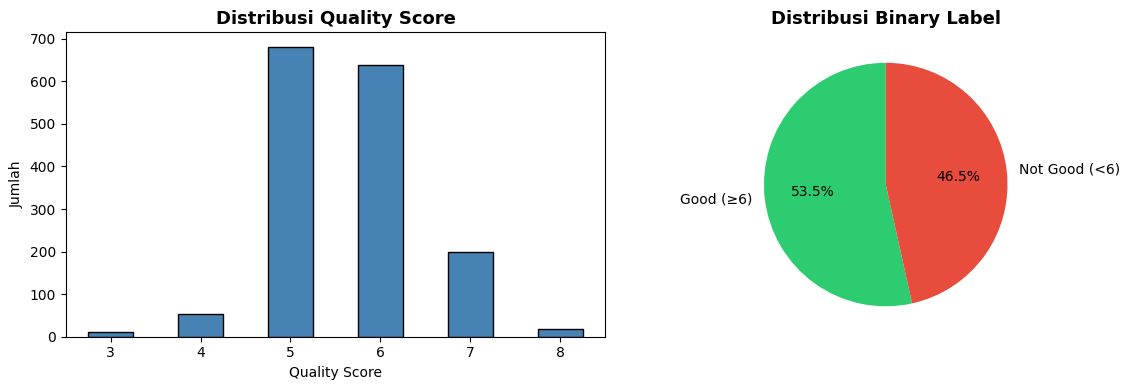

Plot disimpan!


In [20]:
# 4.3 Distribusi Target Variable (quality)
print('=== Distribusi Quality Score ===')
print(df['quality'].value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribusi quality score
df['quality'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Distribusi Quality Score', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Quality Score')
axes[0].set_ylabel('Jumlah')
axes[0].tick_params(axis='x', rotation=0)

# Binary label distribution
binary_quality = (df['quality'] >= 6).map({True: 'Good (≥6)', False: 'Not Good (<6)'})
binary_quality.value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                    colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Distribusi Binary Label', fontsize=13, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('../eda_quality_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print('Plot disimpan!')

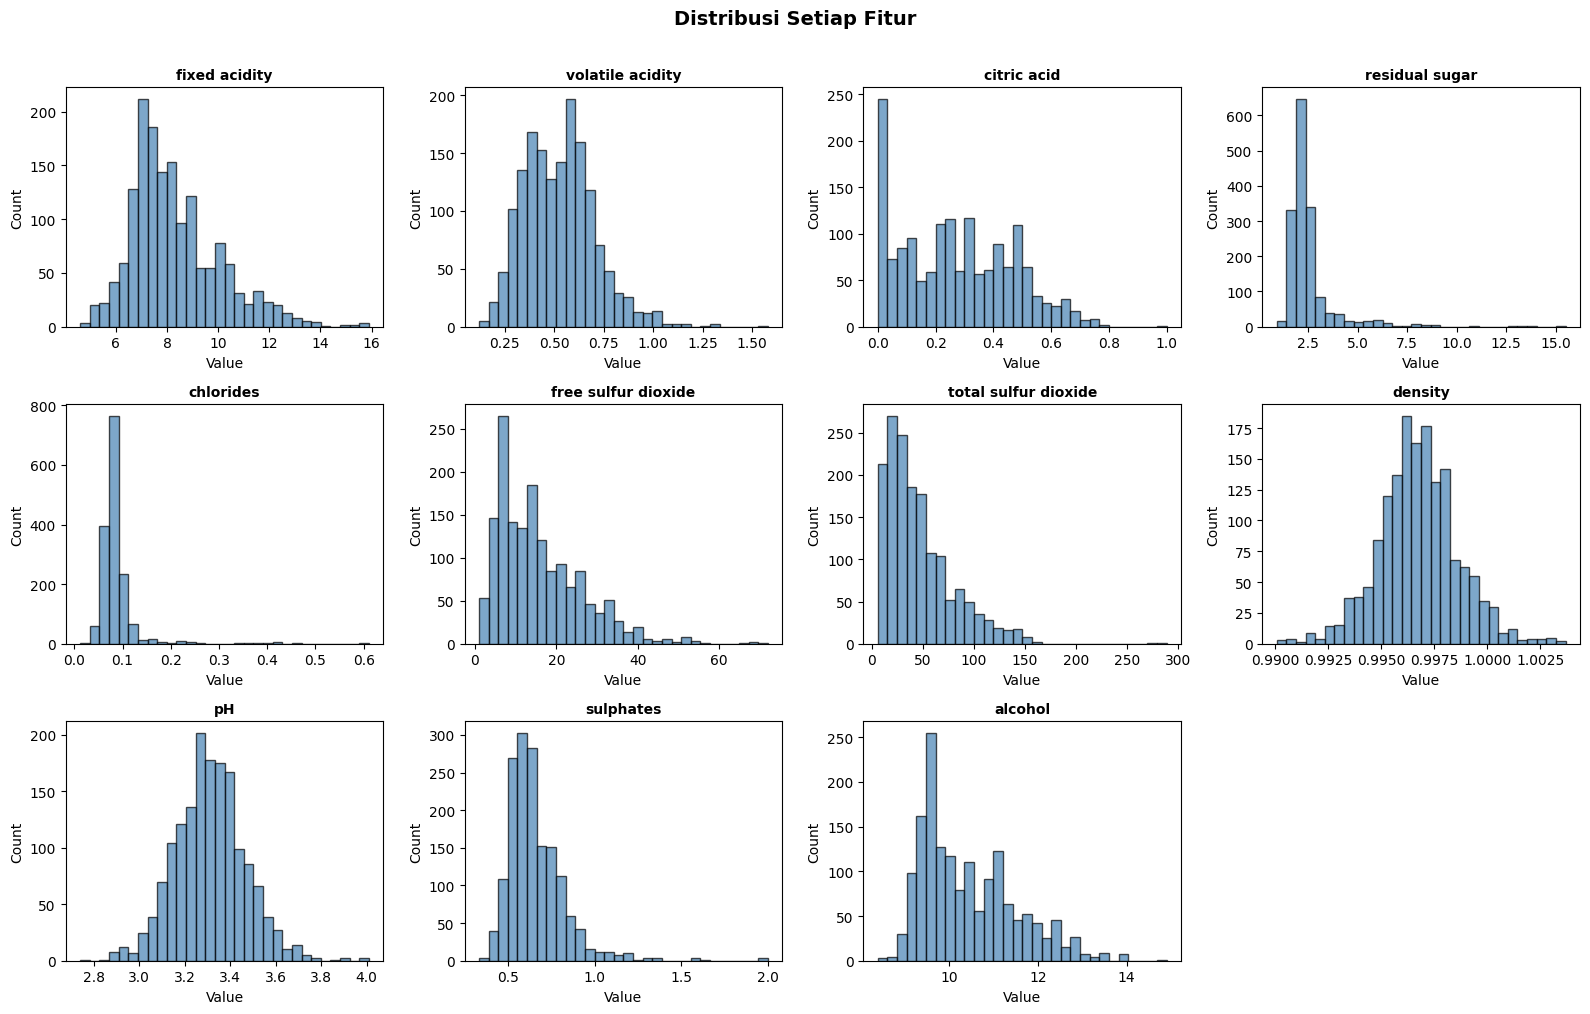

In [21]:
# 4.4 Distribusi Setiap Fitur
features = [c for c in df.columns if c != 'quality']

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

# Sembunyikan subplot kosong
for j in range(len(features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Setiap Fitur', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../eda_feature_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

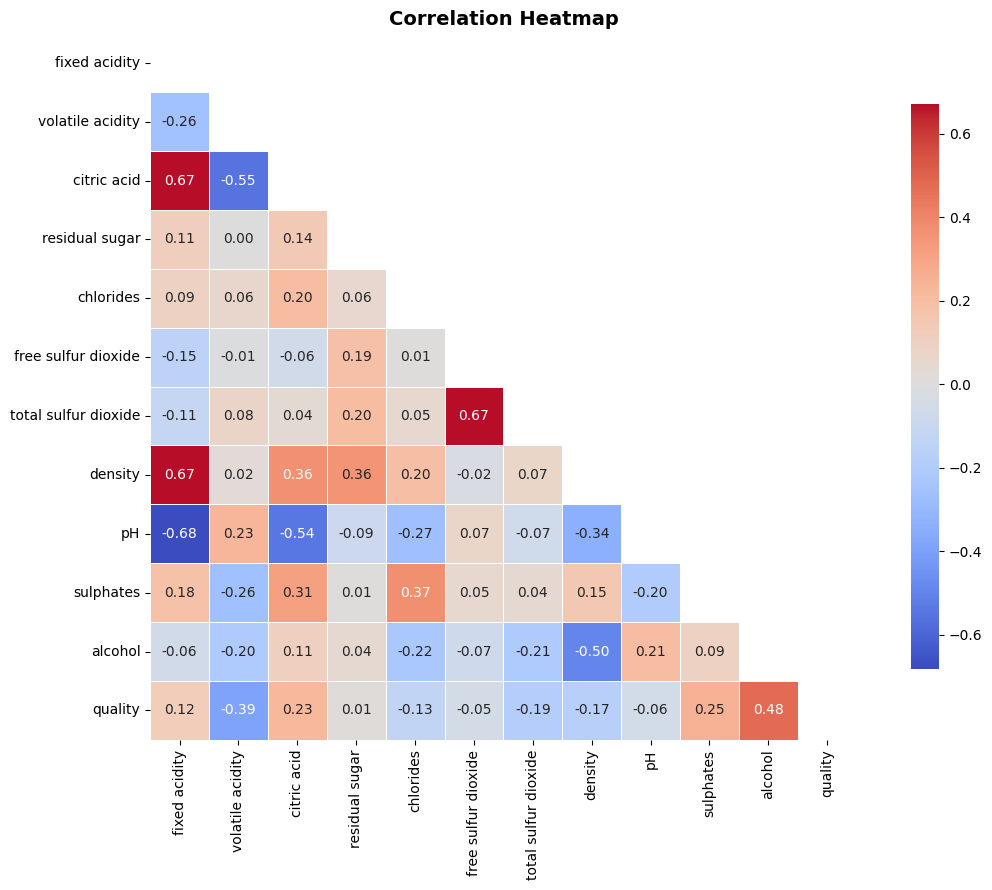


=== Korelasi Fitur dengan Quality ===
alcohol                 0.476
sulphates               0.251
citric acid             0.226
fixed acidity           0.124
residual sugar          0.014
free sulfur dioxide    -0.051
pH                     -0.058
chlorides              -0.129
density                -0.175
total sulfur dioxide   -0.185
volatile acidity       -0.391
Name: quality, dtype: float64


In [22]:
# 4.5 Correlation Heatmap
plt.figure(figsize=(12, 9))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../eda_correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

# Korelasi tertinggi dengan target
print('\n=== Korelasi Fitur dengan Quality ===')
print(corr['quality'].drop('quality').sort_values(ascending=False).round(3))

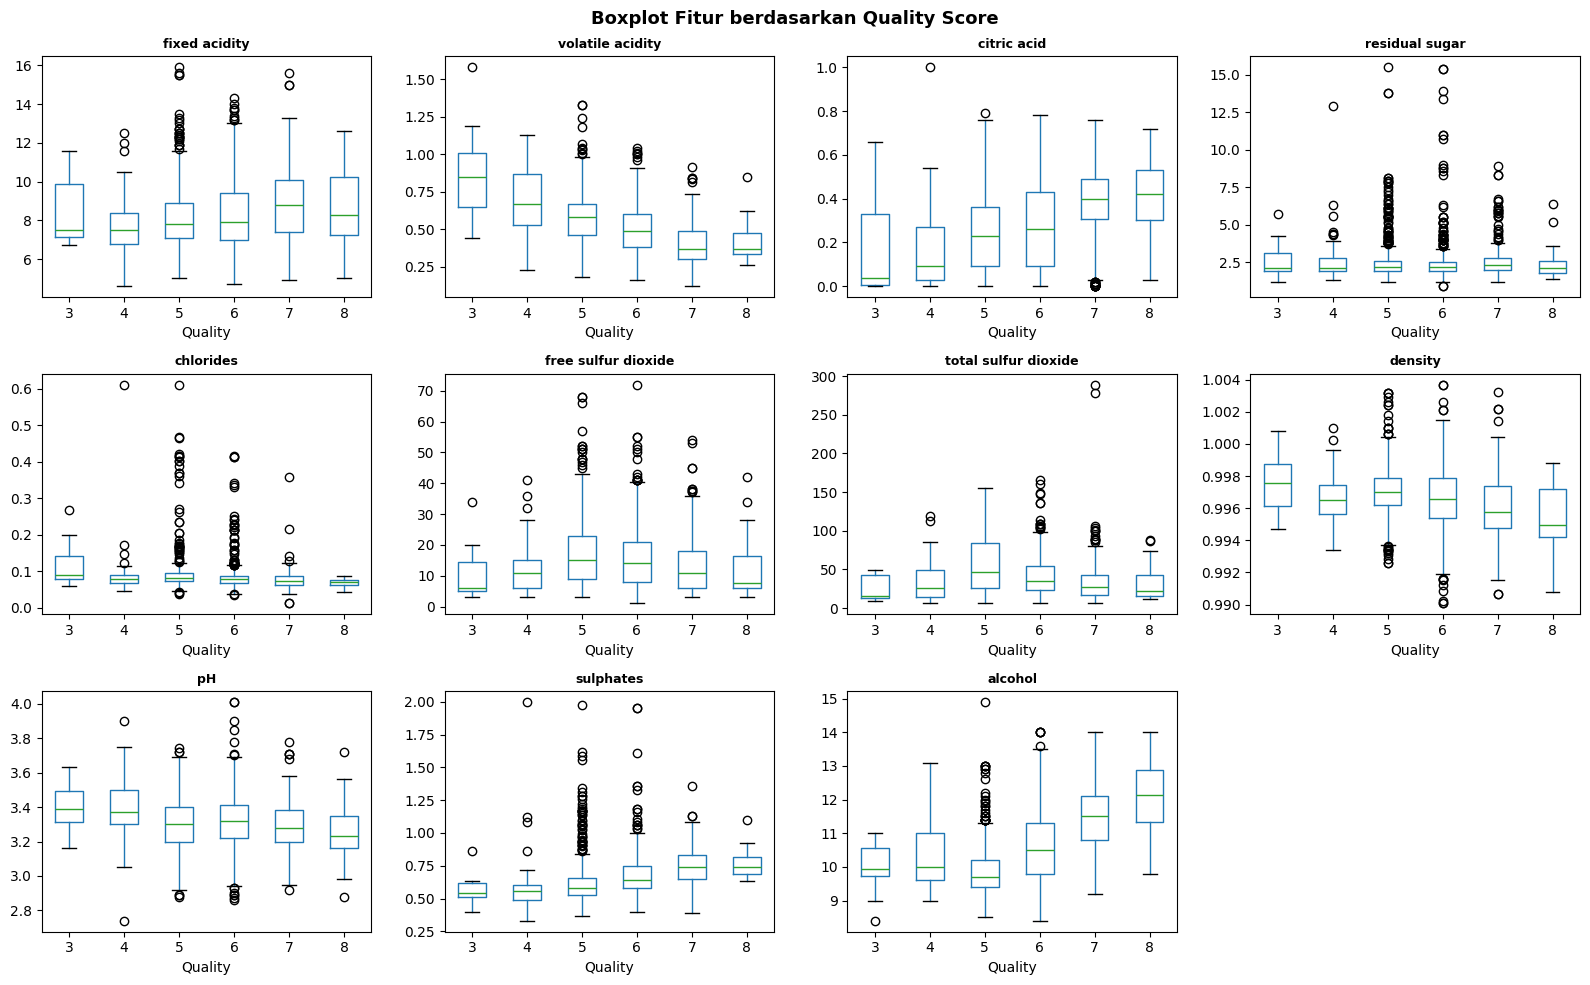

In [23]:
# 4.6 Boxplot – Fitur vs Quality
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    df.boxplot(column=col, by='quality', ax=axes[i], grid=False)
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Quality')

for j in range(len(features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplot Fitur berdasarkan Quality Score', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../eda_boxplot_features.png', dpi=100, bbox_inches='tight')
plt.show()

In [24]:
# 4.7 Deteksi Outlier dengan IQR
print('=== Deteksi Outlier (IQR Method) ===')
outlier_summary = []
for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({
        'Feature': col,
        'Q1': round(Q1, 3),
        'Q3': round(Q3, 3),
        'IQR': round(IQR, 3),
        'Lower Bound': round(lower, 3),
        'Upper Bound': round(upper, 3),
        'Outliers Count': n_outliers,
        'Outliers %': round(n_outliers/len(df)*100, 2)
    })

pd.DataFrame(outlier_summary).set_index('Feature')

=== Deteksi Outlier (IQR Method) ===


,Q1,Q3,IQR,Lower Bound,Upper Bound,Outliers Count,Outliers %
Feature,,,,,,,
fixed acidity,7.100,9.200,2.100,3.950,12.350,49,3.06
volatile acidity,0.390,0.640,0.250,0.015,1.015,19,1.19
citric acid,0.090,0.420,0.330,-0.405,0.915,1,0.06
residual sugar,1.900,2.600,0.700,0.850,3.650,155,9.69
chlorides,0.070,0.090,0.020,0.040,0.120,112,7.00
free sulfur dioxide,7.000,21.000,14.000,-14.000,42.000,30,1.88
total sulfur dioxide,22.000,62.000,40.000,-38.000,122.000,55,3.44
density,0.996,0.998,0.002,0.992,1.001,45,2.81
pH,3.210,3.400,0.190,2.925,3.685,35,2.19


# **5. Data Preprocessing**

Melakukan preprocessing data sebelum digunakan untuk pelatihan model:
1. Membuat binary label dari quality score
2. Menghapus duplikat
3. Menangani outlier dengan IQR capping
4. Feature selection (drop fitur dengan korelasi rendah)
5. Normalisasi fitur dengan StandardScaler
6. Train-test split
7. Simpan hasil preprocessing

In [25]:
# 5.1 Buat binary target label
df_proc = df.copy()
df_proc['quality_label'] = (df_proc['quality'] >= 6).astype(int)
print('=== Binary Label Dibuat ===')
print(df_proc['quality_label'].value_counts())
print(f'\nLabel 1 (Good wine): {df_proc["quality_label"].sum()} ({df_proc["quality_label"].mean()*100:.1f}%)')
print(f'Label 0 (Not good): {(df_proc["quality_label"]==0).sum()} ({(df_proc["quality_label"]==0).mean()*100:.1f}%)')

=== Binary Label Dibuat ===
quality_label
1    855
0    744
Name: count, dtype: int64

Label 1 (Good wine): 855 (53.5%)
Label 0 (Not good): 744 (46.5%)


In [26]:
# 5.2 Hapus duplikat
before = len(df_proc)
df_proc = df_proc.drop_duplicates()
after = len(df_proc)
print(f'=== Hapus Duplikat ===')
print(f'Sebelum: {before} baris')
print(f'Sesudah: {after} baris')
print(f'Terhapus: {before - after} baris')

=== Hapus Duplikat ===
Sebelum: 1599 baris
Sesudah: 1359 baris
Terhapus: 240 baris


In [27]:
# 5.3 Tangani Missing Values (jika ada)
if df_proc.isnull().sum().sum() > 0:
    print('Ada missing values, mengisi dengan median...')
    for col in features:
        df_proc[col].fillna(df_proc[col].median(), inplace=True)
else:
    print('Tidak ada missing values. Langkah ini dilewati.')

Tidak ada missing values. Langkah ini dilewati.


In [28]:
# 5.4 Tangani Outlier dengan IQR Capping (Winsorization)
print('=== Outlier Capping (IQR Method) ===')
df_before_cap = df_proc.copy()

for col in features:
    Q1 = df_proc[col].quantile(0.25)
    Q3 = df_proc[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_proc[col] = df_proc[col].clip(lower, upper)

print('Outlier capping selesai (nilai di-clip ke batas IQR)')
print(f'Dataset shape: {df_proc.shape}')

=== Outlier Capping (IQR Method) ===
Outlier capping selesai (nilai di-clip ke batas IQR)
Dataset shape: (1359, 13)


In [29]:
# 5.5 Pisahkan Features dan Target
X = df_proc[features]
y = df_proc['quality_label']

print(f'=== Features dan Target ===')
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'Features: {features}')

=== Features dan Target ===
X shape: (1359, 11)
y shape: (1359,)
Features: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


In [30]:
# 5.6 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'=== Train-Test Split ===')
print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')
print(f'y_train distribusi: {y_train.value_counts().to_dict()}')
print(f'y_test distribusi: {y_test.value_counts().to_dict()}')

=== Train-Test Split ===
X_train: (1087, 11), X_test: (272, 11)
y_train distribusi: {1: 575, 0: 512}
y_test distribusi: {1: 144, 0: 128}


In [31]:
# 5.7 Normalisasi/Standarisasi dengan StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=features)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=features)

print('=== Normalisasi Selesai ===')
print(f'Mean sebelum scaling (X_train): {X_train[features[0]].mean():.3f}')
print(f'Mean sesudah scaling (X_train): {X_train_scaled[features[0]].mean():.6f}')
print(f'Std sesudah scaling (X_train): {X_train_scaled[features[0]].std():.6f}')

=== Normalisasi Selesai ===
Mean sebelum scaling (X_train): 8.277
Mean sesudah scaling (X_train): -0.000000
Std sesudah scaling (X_train): 1.000460


In [33]:
# 5.8 Simpan hasil preprocessing
OUTPUT_DIR = r'C:\Users\ignas\OneDrive\Desktop\Tugas\Pijak\Eksperimen_SML_Ignasius-David-Christian-Hasugian\preprocessing\winequality_preprocessing'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Gabungkan kembali X dan y
train_df = X_train_scaled.copy()
train_df['quality_label'] = y_train.values

test_df = X_test_scaled.copy()
test_df['quality_label'] = y_test.values

train_df.to_csv(f'{OUTPUT_DIR}/winequality_train.csv', index=False)
test_df.to_csv(f'{OUTPUT_DIR}/winequality_test.csv', index=False)

print(f'=== Data Berhasil Disimpan ===')
print(f'Train set: {OUTPUT_DIR}/winequality_train.csv ({train_df.shape})')
print(f'Test set:  {OUTPUT_DIR}/winequality_test.csv ({test_df.shape})')

=== Data Berhasil Disimpan ===
Train set: C:\Users\ignas\OneDrive\Desktop\Tugas\Pijak\Eksperimen_SML_Ignasius-David-Christian-Hasugian\preprocessing\winequality_preprocessing/winequality_train.csv ((1087, 12))
Test set:  C:\Users\ignas\OneDrive\Desktop\Tugas\Pijak\Eksperimen_SML_Ignasius-David-Christian-Hasugian\preprocessing\winequality_preprocessing/winequality_test.csv ((272, 12))


In [37]:
# 5.9 Verifikasi hasil akhir
print('=== Verifikasi Hasil Preprocessing ===')
train_check = pd.read_csv(f'{OUTPUT_DIR}/winequality_train.csv')
test_check = pd.read_csv(f'{OUTPUT_DIR}/winequality_test.csv')

print(f'Train - Shape: {train_check.shape}, Missing: {train_check.isnull().sum().sum()}')
print(f'Test  - Shape: {test_check.shape}, Missing: {test_check.isnull().sum().sum()}')
print('\nContoh 3 baris train set:')
train_check.head(3)

=== Verifikasi Hasil Preprocessing ===
Train - Shape: (1087, 12), Missing: 0
Test  - Shape: (272, 12), Missing: 0

Contoh 3 baris train set:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality_label
0,-0.829414,-0.444946,-0.827953,0.105970,-2.056841,-0.990116,-1.089291,-1.772459,-0.073088,0.004644,0.896757,1
1,-0.829414,-0.500964,-1.386729,-1.532563,-0.601777,1.679857,-0.254474,-1.303172,0.061854,-0.507427,0.896757,1
2,-0.046380,-0.556982,0.086408,-1.204857,-0.008974,1.166401,-0.029716,-0.381358,-0.410443,-0.800038,-0.128880,0
